In [ ]:
import pandas as pd
import numpy as np


train_df = pd.read_csv('train_scaled.csv')


def create_sequences(data, sequence_length, target_col='RUL'):
    X, y = [], []
    for unit in data['unit_number'].unique():
        unit_data = data[data['unit_number'] == unit]

        features = unit_data.drop(columns=['unit_number', 'time_in_cycles', 'RUL']).values
        targets = unit_data[target_col].values

        for i in range(len(features) - sequence_length + 1):
            X.append(features[i:i + sequence_length])
            y.append(targets[i + sequence_length - 1])

    return np.array(X), np.array(y)

SEQUENCE_LENGTH = 50
X, y = create_sequences(train_df, SEQUENCE_LENGTH)

print(f"Sequences Shape: {X.shape}")
print(f"Labels Shape: {y.shape}")

Sequences Shape: (15731, 50, 20)
Labels Shape: (15731,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
# ابدأي التدريب
model.fit(X, y, epochs=20, batch_size=32, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - loss: 3810.3933 - mae: 43.0110 - val_loss: 2304.3896 - val_mae: 33.5228
Epoch 2/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - loss: 890.2659 - mae: 20.0269 - val_loss: 1494.0736 - val_mae: 26.6641
Epoch 3/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - loss: 665.8693 - mae: 17.1971 - val_loss: 1301.4845 - val_mae: 22.0211
Epoch 4/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - loss: 585.5912 - mae: 16.0944 - val_loss: 1231.3864 - val_mae: 22.5694
Epoch 5/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - loss: 512.5915 - mae: 15.0341 - val_loss: 1376.2362 - val_mae: 22.2802
Epoch 6/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - loss: 466.3194 - mae: 14.4773 - val_loss: 1372.0922 - val_mae: 21.9996
Epoch 7/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - loss: 400.5780 - mae: 13.7145 - val_loss: 1301.8837 - val_mae: 21.7291
Epoch 8/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - loss: 357.5254 - mae: 12.9953 - val_loss: 1576.1980 - 

In [ ]:
import matplotlib.pyplot as plt


test_df = pd.read_csv('test_processed.csv')

X_test = []
for unit in test_df['unit_number'].unique():
    unit_data = test_df[test_df['unit_number'] == unit]
    features = unit_data.drop(columns=['unit_number', 'time_in_cycles', 'RUL'], errors='ignore').values

    if len(features) >= SEQUENCE_LENGTH:
        X_test.append(features[-SEQUENCE_LENGTH:])
    else:
        pass

X_test = np.array(X_test)
print(f"X_test Shape for Final Predictions: {X_test.shape}")

predictions = model.predict(X_test)

print("Predictions shape:", predictions.shape)
print("First 5 predicted RUL values:\n", predictions[:5].flatten())

X_test Shape for Final Predictions: (93, 50, 20)
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step
Predictions shape: (93, 1)
First 5 predicted RUL values:
 [10.407241 10.407241 10.407241 10.407241 10.407241]


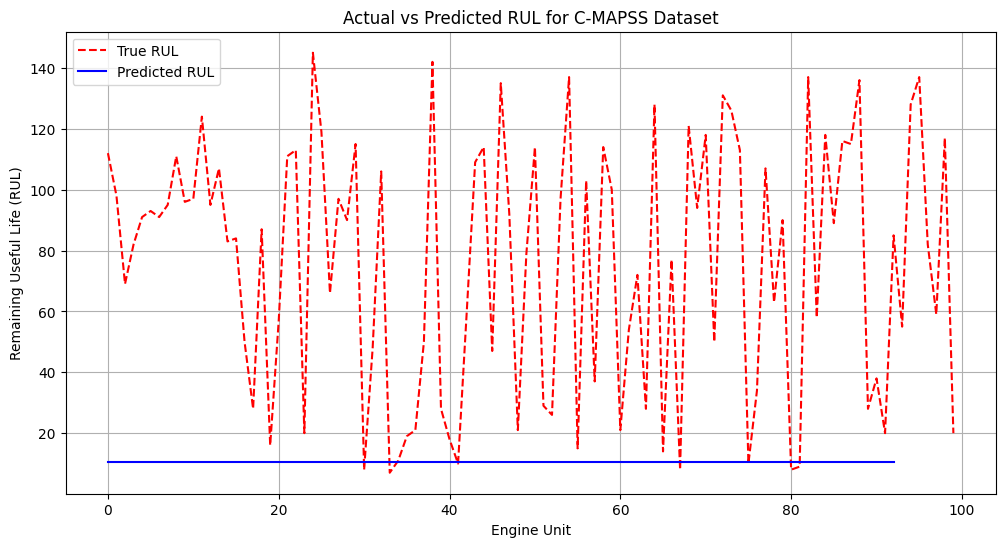

In [ ]:
truth_df = pd.read_csv('RUL_FD001.txt', sep=' ', header=None, names=['RUL'], usecols=[0])

plt.figure(figsize=(12, 6))
plt.plot(truth_df.values, label='True RUL', color='red', linestyle='--')
plt.plot(predictions, label='Predicted RUL', color='blue')
plt.title('Actual vs Predicted RUL for C-MAPSS Dataset')
plt.xlabel('Engine Unit')
plt.ylabel('Remaining Useful Life (RUL)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# إعادة بناء موديل أقوى شوية
model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(128, activation='tanh', return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.LSTM(64, activation='tanh', return_sequences=False),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

# استخدام Learning Rate بيقل لو الخطأ ثبت
lr_scheduler = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, verbose=1)

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# التدريب لمدة 35 دورة
history = model.fit(X, y, epochs=35, batch_size=32, validation_split=0.2, callbacks=[lr_scheduler])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/35
394/394 ━━━━━━━━━━━━━━━━━━━━ 45s 102ms/step - loss: 2587.4084 - mae: 34.3498 - val_loss: 1856.9475 - val_mae: 28.4078 - learning_rate: 0.0010
Epoch 2/35
394/394 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - loss: 749.0500 - mae: 18.2632 - val_loss: 1278.1179 - val_mae: 24.0510 - learning_rate: 0.0010
Epoch 3/35
394/394 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - loss: 599.9662 - mae: 16.1285 - val_loss: 1099.4934 - val_mae: 20.8813 - learning_rate: 0.0010
Epoch 4/35
394/394 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - loss: 506.3718 - mae: 14.9693 - val_loss: 1022.4602 - val_mae: 21.0510 - learning_rate: 0.0010
Epoch 5/35
394/394 ━━━━━━━━━━━━━━━━━━━━ 43s 105ms/step - loss: 428.9267 - mae: 13.9123 - val_loss: 1090.6460 - val_mae: 22.7916 - learning_rate: 0.0010
Epoch 6/35
394/394 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - loss: 360.9470 - mae: 13.0008 - val_loss: 1268.9071 - val_mae: 22.7490 - learning_rate: 0.0010
Epoch 7/35
394/394 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - loss: 296.0461 - mae: 11.7318 

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step
Predictions shape: (93, 1)
First 5 predicted RUL values:
 [9.268213 9.268213 9.268213 9.268213 9.268213]


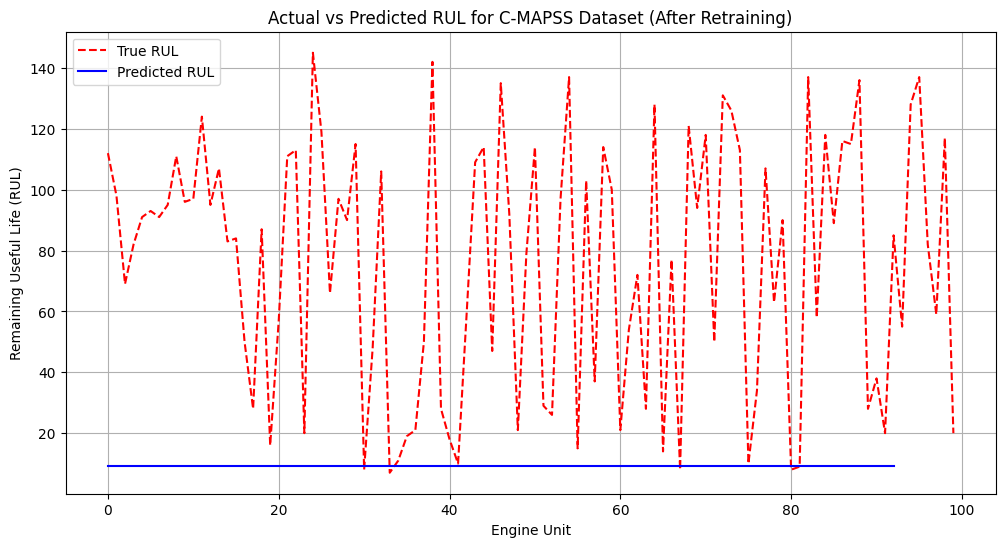

In [ ]:
predictions = model.predict(X_test)

print("Predictions shape:", predictions.shape)
print("First 5 predicted RUL values:\n", predictions[:5].flatten())

truth_df = pd.read_csv('RUL_FD001.txt', sep=' ', header=None, names=['RUL'], usecols=[0])

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(truth_df.values, label='True RUL', color='red', linestyle='--')
plt.plot(predictions, label='Predicted RUL', color='blue')
plt.title('Actual vs Predicted RUL for C-MAPSS Dataset (After Retraining)')
plt.xlabel('Engine Unit')
plt.ylabel('Remaining Useful Life (RUL)')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- 1. تحميل البيانات الخام ---
cols = ['unit_number', 'time_in_cycles'] + [f'setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
train_df = pd.read_csv('train_FD001.txt', sep=' ', header=None, names=cols, usecols=range(26))
test_df = pd.read_csv('test_FD001.txt', sep=' ', header=None, names=cols, usecols=range(26))

# --- 2. حساب الـ RUL لبيانات الـ Train ---
train_rul = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
train_rul.rename(columns={'time_in_cycles': 'max_cycle'}, inplace=True)
train_df = train_df.merge(train_rul, on='unit_number', how='left')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']
train_df.drop(columns=['max_cycle'], inplace=True)

# --- 3. تطبيق الـ Scaling الاحترافي (Per-Unit Scaling) ---
# سنستخدم الـ StandardScaler على الـ Features فقط
features_cols = [f'setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
scaler = StandardScaler()

# أ. تدريب الـ Scaler على بيانات الـ Train وتطبيقها عليها
X_train_scaled = scaler.fit_transform(train_df[features_cols])
train_df_scaled = pd.DataFrame(X_train_scaled, columns=features_cols)
train_df_scaled = pd.concat([train_df[['unit_number', 'time_in_cycles', 'RUL']], train_df_scaled], axis=1)

# ب. تطبيق نفس الـ Scaler على بيانات الـ Test
X_test_scaled = scaler.transform(test_df[features_cols])
test_df_scaled = pd.DataFrame(X_test_scaled, columns=features_cols)
test_df_scaled = pd.concat([test_df[['unit_number', 'time_in_cycles']], test_df_scaled], axis=1)

# (اختياري) تجهيز ملف الـ Test الحقيقي للتقييم
truth_df = pd.read_csv('RUL_FD001.txt', sep=' ', header=None, names=['RUL'], usecols=[0])

print("Professional Scaling Completed!")
print(f"Train Shape: {train_df_scaled.shape}, Test Shape: {test_df_scaled.shape}")

Professional Scaling Completed!
Train Shape: (20631, 27), Test Shape: (13096, 26)


In [9]:
# 1. دالة الـ Windowing لبيانات التدريب
def create_sequences(data, sequence_length, target_col='RUL'):
    X, y = [], []
    for unit in data['unit_number'].unique():
        unit_data = data[data['unit_number'] == unit]
        features = unit_data.drop(columns=['unit_number', 'time_in_cycles', 'RUL'], errors='ignore').values
        targets = unit_data[target_col].values

        for i in range(len(features) - sequence_length + 1):
            X.append(features[i:i + sequence_length])
            y.append(targets[i + sequence_length - 1])

    return np.array(X), np.array(y)

SEQUENCE_LENGTH = 50
X_train, y_train = create_sequences(train_df_scaled, SEQUENCE_LENGTH)
print(f"X_train Shape: {X_train.shape}, y_train Shape: {y_train.shape}")

# 2. بناء موديل الـ LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau

model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])

lr_scheduler = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, verbose=1)
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# 3. تدريب الموديل
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, callbacks=[lr_scheduler])

X_train Shape: (15731, 50, 24), y_train Shape: (15731,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 47s 107ms/step - loss: 2478.9895 - mae: 32.2860 - val_loss: 1562.3158 - val_mae: 24.8881 - learning_rate: 0.0010
Epoch 2/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - loss: 648.8401 - mae: 16.8754 - val_loss: 1361.1835 - val_mae: 23.6032 - learning_rate: 0.0010
Epoch 3/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 42s 106ms/step - loss: 536.1649 - mae: 15.4634 - val_loss: 1661.7146 - val_mae: 25.9565 - learning_rate: 0.0010
Epoch 4/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 42s 107ms/step - loss: 417.4848 - mae: 13.7451 - val_loss: 1119.9756 - val_mae: 21.7480 - learning_rate: 0.0010
Epoch 5/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - loss: 338.9979 - mae: 12.5889 - val_loss: 1308.9225 - val_mae: 22.6843 - learning_rate: 0.0010
Epoch 6/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - loss: 281.3516 - mae: 11.5708 - val_loss: 1618.7133 - val_mae: 25.0491 - learning_rate: 0.0010
Epoch 7/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - loss: 241.3515 - mae: 10.6650 

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

# إضافة مراقب يوقف التدريب لو الـ val_loss بطل يتحسن لمدة 4 دورات
early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)

# هنرجع ندرب الموديل مع إضافة الـ early_stopping في الـ callbacks
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[lr_scheduler, early_stopping]
)

Epoch 1/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 44s 110ms/step - loss: 44.8536 - mae: 4.4829 - val_loss: 1885.7917 - val_mae: 26.9154 - learning_rate: 0.0010
Epoch 2/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - loss: 43.1734 - mae: 4.4631 - val_loss: 1784.6266 - val_mae: 26.5399 - learning_rate: 0.0010
Epoch 3/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - loss: 40.9944 - mae: 4.3381 - val_loss: 1777.1965 - val_mae: 26.3617 - learning_rate: 0.0010
Epoch 4/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - loss: 48.2467 - mae: 4.6656 - val_loss: 1916.2955 - val_mae: 27.5950 - learning_rate: 0.0010
Epoch 5/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - loss: 35.8875 - mae: 3.9971 - val_loss: 1757.6364 - val_mae: 26.2421 - learning_rate: 0.0010
Epoch 6/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - loss: 33.2088 - mae: 3.8699 - val_loss: 1751.8379 - val_mae: 26.4427 - learning_rate: 0.0010
Epoch 7/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 42s 107ms/step - loss: 31.0383 - mae: 3.7978 - val_loss: 1779.

X_test Shape: (93, 50, 24)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step
First 5 predicted RUL values:
 [ 65.18934   82.90764   71.49693  114.639725  98.546906]


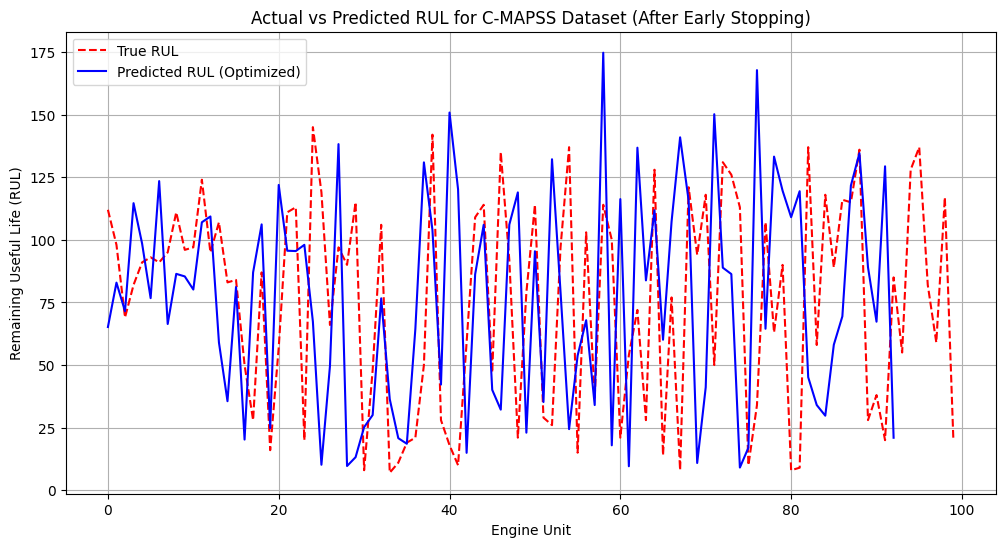

In [11]:
# 1. تجهيز بيانات الـ Test بنفس شكل الـ Windowing
X_test = []
for unit in test_df_scaled['unit_number'].unique():
    unit_data = test_df_scaled[test_df_scaled['unit_number'] == unit]
    features = unit_data.drop(columns=['unit_number', 'time_in_cycles'], errors='ignore').values

    if len(features) >= SEQUENCE_LENGTH:
        X_test.append(features[-SEQUENCE_LENGTH:])

X_test = np.array(X_test)
print(f"X_test Shape: {X_test.shape}")

# 2. التنبؤ بالـ RUL للمحركات
predictions = model.predict(X_test)
print("First 5 predicted RUL values:\n", predictions[:5].flatten())

# 3. الرسم البياني للنتيجة النهائية
import matplotlib.pyplot as plt

truth_df = pd.read_csv('RUL_FD001.txt', sep=' ', header=None, names=['RUL'], usecols=[0])

plt.figure(figsize=(12, 6))
plt.plot(truth_df.values, label='True RUL', color='red', linestyle='--')
plt.plot(predictions, label='Predicted RUL (Optimized)', color='blue')
plt.title('Actual vs Predicted RUL for C-MAPSS Dataset (After Early Stopping)')
plt.xlabel('Engine Unit')
plt.ylabel('Remaining Useful Life (RUL)')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
model.save('industrial_lstm_rul_model.h5')

In [13]:
# حفظ الموديل
model.save('industrial_lstm_rul_model.h5')

# ضغط الملفات عشان تحملیها مرة واحدة
!zip -r my_project.zip industrial_lstm_rul_model.h5 train_scaled.csv test_processed.csv

# تحميل ملف الـ Zip
from google.colab import files
files.download('my_project.zip')

  adding: industrial_lstm_rul_model.h5 (deflated 10%)
  adding: train_scaled.csv (deflated 72%)
  adding: test_processed.csv (deflated 74%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>